# CNN - Konvolüsyon Sinir Ağları - Rice_Image_Dataset

Bu projede 4 pirinç çeşitlerinden hangisi olduğunu algılayan bir cnn modeli geliştireceğiz.

In [1]:
#!pip install opencv-python

In [2]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D,Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Arborio Basmati Ipsala Jasmine Karacadag

In [5]:
labels=['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
img_path='Rice_Image_Dataset/'

In [6]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+"/"+img_file)
        label_list.append(label)

In [7]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [8]:
df

,img,label
0,Rice_Image_Dataset/Arborio/Arborio (1).jpg,Arborio
1,Rice_Image_Dataset/Arborio/Arborio (10).jpg,Arborio
2,Rice_Image_Dataset/Arborio/Arborio (100).jpg,Arborio
3,Rice_Image_Dataset/Arborio/Arborio (1000).jpg,Arborio
4,Rice_Image_Dataset/Arborio/Arborio (10000).jpg,Arborio
...,...,...
74995,Rice_Image_Dataset/Karacadag/Karacadag (9995).jpg,Karacadag
74996,Rice_Image_Dataset/Karacadag/Karacadag (9996).jpg,Karacadag
74997,Rice_Image_Dataset/Karacadag/Karacadag (9997).jpg,Karacadag
74998,Rice_Image_Dataset/Karacadag/Karacadag (9998).jpg,Karacadag


In [9]:
d=({'Arborio':0, 'Basmati':1, 'Ipsala':2, 'Jasmine':3, 'Karacadag':4})
df['label_encoded']=df['label'].map(d)

In [10]:
df

,img,label,label_encoded
0,Rice_Image_Dataset/Arborio/Arborio (1).jpg,Arborio,0
1,Rice_Image_Dataset/Arborio/Arborio (10).jpg,Arborio,0
2,Rice_Image_Dataset/Arborio/Arborio (100).jpg,Arborio,0
3,Rice_Image_Dataset/Arborio/Arborio (1000).jpg,Arborio,0
4,Rice_Image_Dataset/Arborio/Arborio (10000).jpg,Arborio,0
...,...,...,...
74995,Rice_Image_Dataset/Karacadag/Karacadag (9995).jpg,Karacadag,4
74996,Rice_Image_Dataset/Karacadag/Karacadag (9996).jpg,Karacadag,4
74997,Rice_Image_Dataset/Karacadag/Karacadag (9997).jpg,Karacadag,4
74998,Rice_Image_Dataset/Karacadag/Karacadag (9998).jpg,Karacadag,4


In [11]:
x=[] # bos liste
for img in df['img']:
    img=cv2.imread(str(img))
    if img is not None:
        img=cv2.resize(img,(64,64))
        img=img/255.0 # normalize et
        x.append(img)
    else:
        print(f" Failed to read image {img}")

In [12]:
y=df['label_encoded']

In [13]:
x=np.array(x)

In [14]:
x

array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],


       [[[0., 0., 0.],
         [0., 0., 0.],
         [0., 

In [15]:
x.shape

(75000, 64, 64, 3)

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.2, stratify=y)

In [17]:
y_train=np.array(y_train, dtype=np.int32)
y_test=np.array(y_test, dtype=np.int32)

In [18]:
model=Sequential()
model.add(Input(shape=(64, 64, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Added activation function
model.add(Dense(5, activation='softmax'))  # Ensure 2 classes for binary classification

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(x_train,y_train, validation_data=(x_test,y_test), epochs=10, batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 136s 71ms/step - accuracy: 0.9590 - loss: 0.1206 - val_accuracy: 0.9717 - val_loss: 0.0859
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 72ms/step - accuracy: 0.9809 - loss: 0.0570 - val_accuracy: 0.9901 - val_loss: 0.0307
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 134s 72ms/step - accuracy: 0.9893 - loss: 0.0318 - val_accuracy: 0.9925 - val_loss: 0.0240
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 154s 78ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9945 - val_loss: 0.0168
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 201s 77ms/step - accuracy: 0.9951 - loss: 0.0149 - val_accuracy: 0.9961 - val_loss: 0.0132
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 203s 78ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accuracy: 0.9962 - val_loss: 0.0118
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 189s 71ms/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 0.9907 - val_loss: 0.0271
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 153s 77ms/step - accuracy: 

In [23]:
model.save('rice_model.keras')

In [24]:
model.save('rice_model.h5')

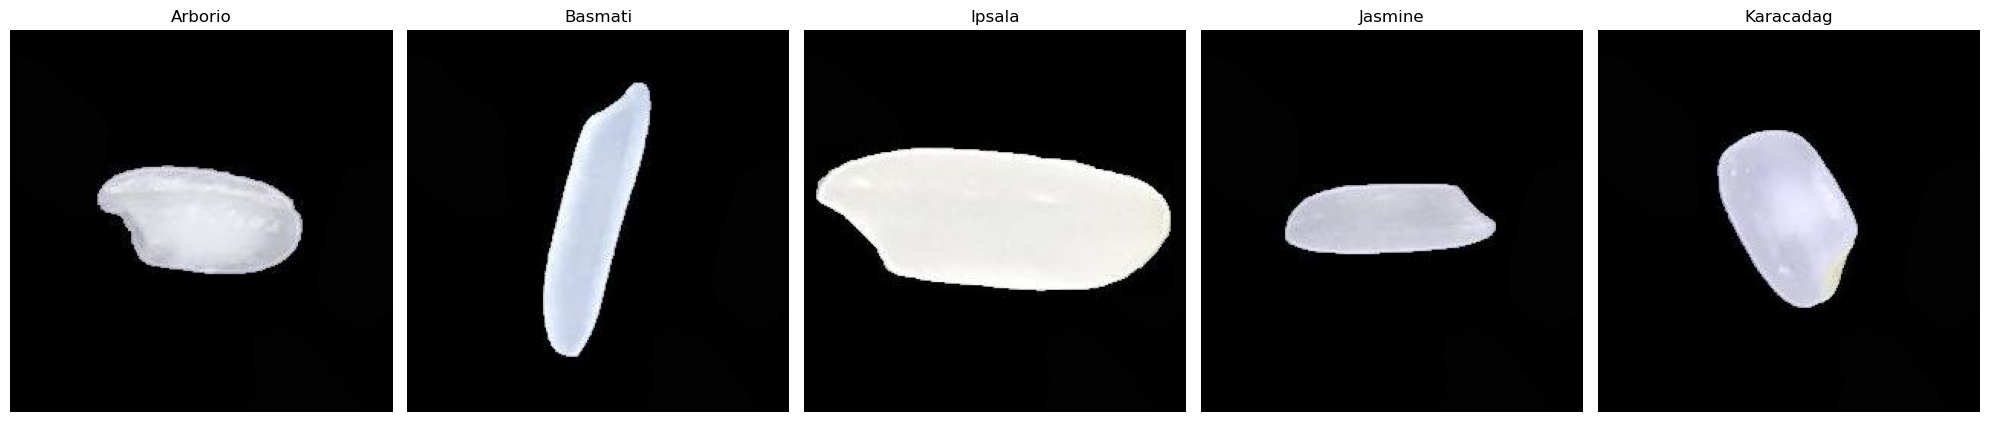

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
labels = sorted([d for d in os.listdir(img_path) if os.path.isdir(os.path.join(img_path, d))])

# 1x9 boyutunda bir görsel tablosu oluşturuyoruz
fig, axes = plt.subplots(1, len(labels), figsize=(20, 5))

for i, label in enumerate(labels):
    target_dir = os.path.join(img_path, label)
    images = os.listdir(target_dir)
    
    if images:
        img_full_path = os.path.join(target_dir, images[0]) # İlk resmi seç
        img = Image.open(img_full_path)
        
        # Resmi çizdir ve başlık ekle
        axes[i].imshow(img)
        axes[i].set_title(label, fontsize=12)
    
    axes[i].axis('off') # Eksen çizgilerini kapat

plt.tight_layout()
plt.show()
